## Tema 4 - Listado 1 - Ejercicio 2

Ejercicio para entrenar un modelo simple de red neuronal utilizando la biblioteca Keras de Tensorflow.

In [25]:
import spacy
from tensorflow.keras.preprocessing.sequence import pad_sequences


2025-06-30 15:20:18.431459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-30 15:20:18.444645: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-30 15:20:18.473575: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-30 15:20:18.495105: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751289618.517092   43019 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751289618.52

In [60]:
#Preparar vocabulario
nlp = spacy.load('es_core_news_sm')

def prepare_vocabulary(corpus, vocab_size):
    token_to_idx={}
    id=1 
    for f in corpus:
        doc= nlp(f)
        for token in doc:
            if token.text not in token_to_idx and id < vocab_size:
                token_to_idx[token.text]= id
                id+=1
    
    return token_to_idx

#Prepara datos de entrenamiento -> codifica las palabras según id (0 si no está y aplica padding)

def prepare_sentences(corpus, vocab, max_length):
    encoded_sentences=[]
    for f in corpus:
        encoded_sentence=[]
        doc= nlp(f)
        for token in doc:
            if token.text in vocab:
                id= vocab[token.text]
            else:
                id=0
            encoded_sentence.append(id)
        encoded_sentences.append(encoded_sentence)

    prepared_sentences = pad_sequences(encoded_sentences, maxlen=max_length, padding='post', truncating='post')
    print("Oraciones originales(",len(corpus),"):")
    print(corpus)  
    print("Oraciones procesadas(",len(prepared_sentences),"):")
    print(prepared_sentences)    

    return prepared_sentences


In [ ]:
import pandas as pd

# Cargar el archivo .jsonl
df = pd.read_json("/mnt/c/Users/carme/Desktop/PLN/T4_listados/Tema4Hoja1/train.jsonl", lines=True)

In [61]:

# Filtrar datos solo con etiquetas 0 (negativo) y 2 (positivo)
filtered_data = df.loc[df["label"].isin([0, 2])]

# Convertir etiquetas
labels = [1 if label == 2 else 0 for label in filtered_data["label"]]
texts = filtered_data["text"]


print(f"Ejemplos cargados: {len(texts)}")
print(f"Positivos: {labels.count(1)} - Negativos: {labels.count(0)}")


Ejemplos cargados: 1226
Positivos: 613 - Negativos: 613


In [62]:
vocab_size=5000
max_length=100
vocab= prepare_vocabulary(texts,vocab_size )
encoded_sentences= prepare_sentences(texts, vocab, max_length)

Oraciones originales( 1226 ):
0       estoy hasta el ojete de que me digáis que teng...
2                                Esto de estar feliz mola
3                                  Ya no es tan divertido
5       @user @user @user con una pequeña donación har...
6       He probado una nueva espuma para el pelo y sí ...
                              ...                        
1832    Como me mola ver lo que escuece en la cool dar...
1833    @user igual ese proyecto de ley no va a progre...
1835                     #FF a los magníficos de @user !!
1836    No puedo poner el insta histories ese raro  al...
1838    @user Bellísima. La imagen con el hell-hound m...
Name: text, Length: 1226, dtype: object
Oraciones procesadas( 1226 ):
[[   1    2    3 ...    0    0    0]
 [  13    5   14 ...    0    0    0]
 [  17   18   19 ...    0    0    0]
 ...
 [  34  316   29 ...    0    0    0]
 [ 126  432 1535 ...    0    0    0]
 [  22    0   55 ...    0    0    0]]


Se pide utilizar una CNN para clasificar los tweets en función de su sentimiento. En este
caso, se quiere que se prueben diferentes configuraciones. Se pueden añadir más capas
a la red, capas de convolución, capas densas, etc. Se pueden añadir capas con el método
add. Se trata de experimentar con diferentes arquitecturas cambiando el número y tipo
de capas o ajustando parámetros como el número de neuronas por capa o las funciones
de activación.
Se proporciona también un código para pintar las curvas de aprendizaje. Estas curvas
son gráficos que nos permiten ver cómo el modelo aprende a lo largo de su
entrenamiento. En particular, muestran sus resultados al ser evaluados en cada epoch
sobre su conjunto de entrenamiento y el conjunto de validación. Se pueden mostrar
gráficos distintos para el accuracy y para el error (su comportamiento será opuesto).
Estas curvas se utilizan para diagnosticar si un modelo no es capaz de resolver la tarea,
puede sufrir sobre-aprendizaje (se ajusta perfectamente al conjunto de entrenamiento,
pero no es capaz de resolver el problema en el conjunto de validación), o si el modelo
está bien ajustado

In [63]:
from keras.models import Sequential 
from keras.layers import Dense, Flatten, Embedding, Conv1D, MaxPool1D

In [80]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [81]:
model.build(input_shape=(None, max_length))
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 10)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 96, 64)         │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         3,073 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,337 (220.07 KB)

 Trainable params: 56,337 (220.07 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(980, 100)
(980,)
(246, 100)
(246,)


In [82]:
from sklearn.model_selection import train_test_split
import numpy as np
encoded_sentences= np.array(encoded_sentences)
labels= np.array(labels)

X_train, X_test, y_train, y_test= train_test_split(encoded_sentences,labels, test_size=0.2, random_state=42)

batch_size=32
epochs=8

history= model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=batch_size, epochs=epochs)

Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4986 - loss: 0.6937 - val_accuracy: 0.4959 - val_loss: 0.6931
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6258 - loss: 0.6886 - val_accuracy: 0.5325 - val_loss: 0.6920
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6170 - loss: 0.6762 - val_accuracy: 0.5772 - val_loss: 0.6833
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7354 - loss: 0.6209 - val_accuracy: 0.6463 - val_loss: 0.6239
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8993 - loss: 0.4509 - val_accuracy: 0.7073 - val_loss: 0.5391
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9376 - loss: 0.2377 - val_accuracy: 0.7358 - val_loss: 0.5345
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9814 - loss: 0.1192 - val_accuracy: 0.7317 - val_loss: 0.5581
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9957 - loss: 0.0586 - val_accuracy: 0.7195 - val_loss: 0.5938

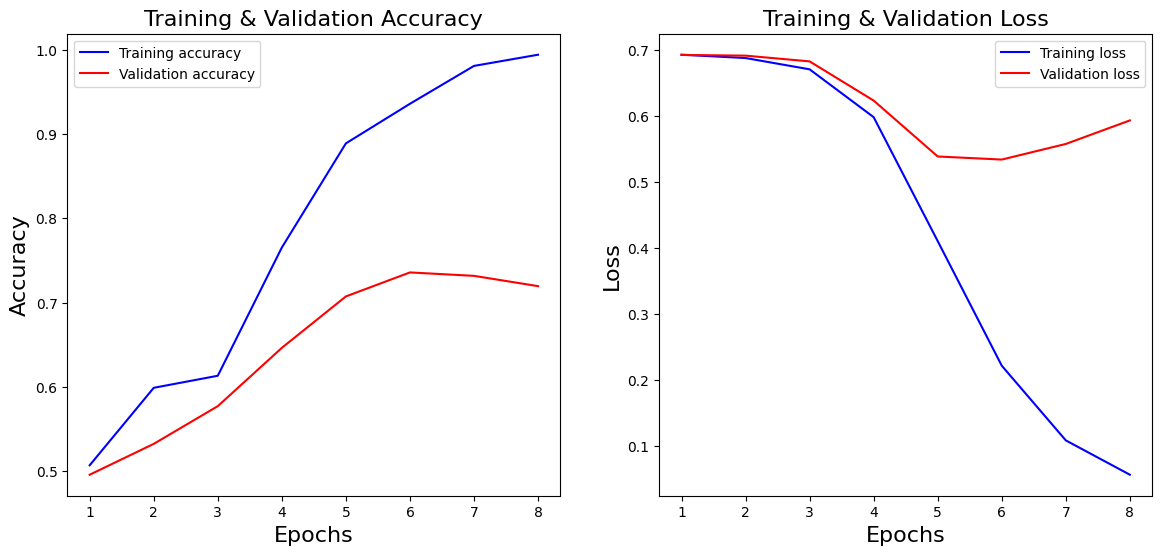

In [84]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Curva accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'b', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Curva loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'b', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()